In [5]:
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

df = sns.load_dataset("titanic")

df = df[["survived", "pclass", "sex", "age", "sibsp", "parch", "fare", "embarked"]]

df["age"] = df["age"].fillna(df["age"].median())
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])

X = df.drop("survived", axis=1)
y = df["survived"]

X = pd.get_dummies(X, columns=["sex", "embarked"], drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

numeric_features = ["pclass", "age", "sibsp", "parch", "fare"]

scaler = StandardScaler()

X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test[numeric_features] = scaler.transform(X_test[numeric_features])

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5]
}

rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring="f1"
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best F1 Score:", grid_search.best_score_)

Best Parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
Best F1 Score: 0.7606238721350002


In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

smote_rf = RandomForestClassifier(
    **grid_search.best_params_,
    random_state=42,
    n_jobs=-1
)

smote_rf.fit(X_train_smote, y_train_smote)

y_pred_smote = smote_rf.predict(X_test)

print("SMOTE Random Forest Results")
print("Accuracy:", accuracy_score(y_test, y_pred_smote))
print("Precision:", precision_score(y_test, y_pred_smote))
print("Recall:", recall_score(y_test, y_pred_smote))
print("F1-Score:", f1_score(y_test, y_pred_smote))

SMOTE Random Forest Results
Accuracy: 0.8156424581005587
Precision: 0.7571428571428571
Recall: 0.7681159420289855
F1-Score: 0.762589928057554


In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from imblearn.over_sampling import SMOTE

print("Original training distribution:")
print(y_train.value_counts())

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Original training distribution:
survived
0    439
1    273
Name: count, dtype: int64

After SMOTE:
survived
1    439
0    439
Name: count, dtype: int64


In [6]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

best_rf = grid_search.best_estimator_

y_pred = best_rf.predict(X_test)

print("Best Random Forest Accuracy:", accuracy_score(y_test, y_pred))
print("Best Random Forest Precision:", precision_score(y_test, y_pred))
print("Best Random Forest Recall:", recall_score(y_test, y_pred))
print("Best Random Forest F1-Score:", f1_score(y_test, y_pred))

Best Random Forest Accuracy: 0.8100558659217877
Best Random Forest Precision: 0.7868852459016393
Best Random Forest Recall: 0.6956521739130435
Best Random Forest F1-Score: 0.7384615384615385


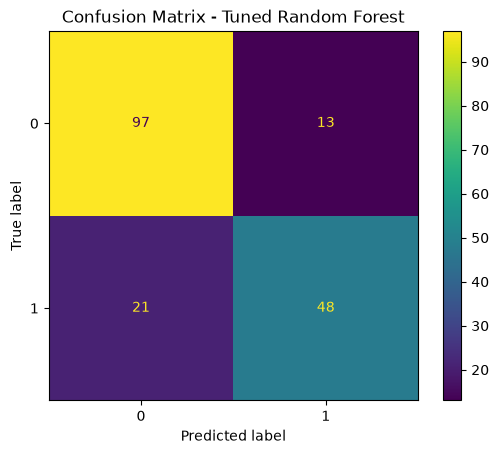

In [7]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[0, 1]
)

disp.plot()
plt.title("Confusion Matrix - Tuned Random Forest")
plt.show()

In [8]:
import joblib

joblib.dump(best_rf, "random_forest_tuned.joblib")

print("Tuned Random Forest saved successfully")

Tuned Random Forest saved successfully


In [9]:
results = {
    "Model": "Tuned Random Forest",
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1-Score": f1_score(y_test, y_pred)
}

final_results = pd.DataFrame([results])

final_results.to_csv("model_results.csv", index=False)

display(final_results)

print("Model results saved successfully")

,Model,Accuracy,Precision,Recall,F1-Score
0,Tuned Random Forest,0.810056,0.786885,0.695652,0.738462


Model results saved successfully


In [12]:
import joblib

X_train_encoded = joblib.load("X_train_encoded.joblib")
y_train = joblib.load("y_train.joblib")

print(X_train_encoded.shape)
print(y_train.shape)

(712, 8)
(712,)


In [13]:
from sklearn.ensemble import RandomForestClassifier

oob_rf = RandomForestClassifier(
    **grid_search.best_params_,
    oob_score=True,
    random_state=42,
    n_jobs=-1
)

oob_rf.fit(X_train_encoded, y_train)

print("OOB Score:", oob_rf.oob_score_)

OOB Score: 0.8258426966292135


Linear Regression Results
MAE: 20.809397730838665
RMSE: 30.473145462848684
R²: 0.39989994844402
Adjusted R²: 0.3753344492575179


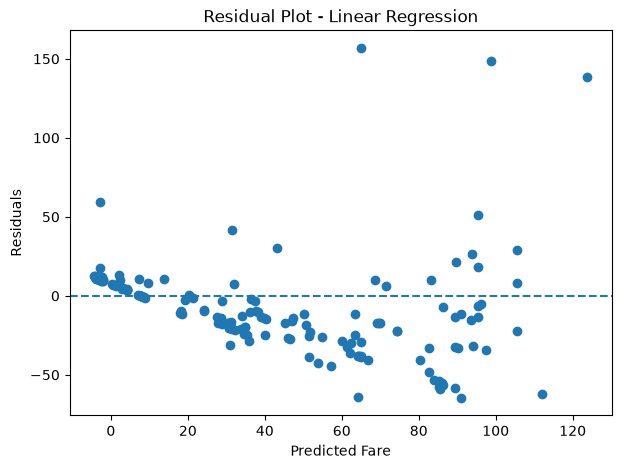

In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

reg_df = df.copy()

X_reg = reg_df[["pclass", "sex", "age", "sibsp", "parch", "embarked"]]
y_reg = reg_df["fare"]

X_reg = pd.get_dummies(
    X_reg,
    columns=["sex", "embarked"],
    drop_first=True
)

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

reg_model = LinearRegression()
reg_model.fit(X_reg_train, y_reg_train)

y_reg_pred = reg_model.predict(X_reg_test)

mae = mean_absolute_error(y_reg_test, y_reg_pred)
rmse = np.sqrt(mean_squared_error(y_reg_test, y_reg_pred))
r2 = r2_score(y_reg_test, y_reg_pred)

n = len(y_reg_test)
p = X_reg_test.shape[1]

adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))

print("Linear Regression Results")
print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)
print("Adjusted R²:", adjusted_r2)

residuals = y_reg_test - y_reg_pred

plt.figure(figsize=(7, 5))
plt.scatter(y_reg_pred, residuals)
plt.axhline(y=0, linestyle="--")
plt.xlabel("Predicted Fare")
plt.ylabel("Residuals")
plt.title("Residual Plot - Linear Regression")
plt.show()

### Residual Analysis

The residuals are not completely randomly distributed around zero. The spread of residuals increases at higher predicted fare values, indicating the presence of heteroscedasticity. This suggests that the variance of prediction errors is not constant across all fare values.

In [15]:
import joblib
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier

numeric_features = ["pclass", "age", "sibsp", "parch", "fare"]
categorical_features = ["sex", "embarked"]

preprocessor = ColumnTransformer([
    ("numeric", StandardScaler(), numeric_features),
    ("categorical", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features)
])

final_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        **grid_search.best_params_,
        random_state=42,
        n_jobs=-1
    ))
])

X_raw = df[["pclass", "sex", "age", "sibsp", "parch", "fare", "embarked"]]
y_raw = df["survived"]

final_pipeline.fit(X_raw, y_raw)

joblib.dump(final_pipeline, "titanic_survival_pipeline.joblib")

loaded_pipeline = joblib.load("titanic_survival_pipeline.joblib")

new_passenger = pd.DataFrame([{
    "pclass": 3,
    "sex": "male",
    "age": 22,
    "sibsp": 1,
    "parch": 0,
    "fare": 7.25,
    "embarked": "S"
}])

prediction = loaded_pipeline.predict(new_passenger)
probability = loaded_pipeline.predict_proba(new_passenger)[0][1]

print("Pipeline saved successfully")
print("Pipeline reloaded successfully")
print("Prediction:", prediction[0])
print("Survival Probability:", round(probability * 100, 2), "%")

Pipeline saved successfully
Pipeline reloaded successfully
Prediction: 0
Survival Probability: 11.9 %


ROC-AUC Score: 0.836231884057971


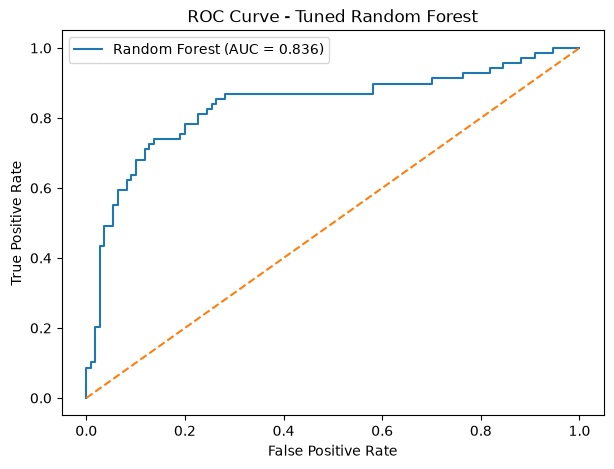

In [17]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_prob = best_rf.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", auc_score)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {auc_score:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Tuned Random Forest")
plt.legend()
plt.show()

In [21]:
print("Original Random Forest")
print("Accuracy:", accuracy_score(y_test, best_rf.predict(X_test)))
print("Precision:", precision_score(y_test, best_rf.predict(X_test)))
print("Recall:", recall_score(y_test, best_rf.predict(X_test)))
print("F1-Score:", f1_score(y_test, best_rf.predict(X_test)))

print("\nSMOTE Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_smote))
print("Precision:", precision_score(y_test, y_pred_smote))
print("Recall:", recall_score(y_test, y_pred_smote))
print("F1-Score:", f1_score(y_test, y_pred_smote))

Original Random Forest
Accuracy: 0.8100558659217877
Precision: 0.7868852459016393
Recall: 0.6956521739130435
F1-Score: 0.7384615384615385

SMOTE Random Forest
Accuracy: 0.8156424581005587
Precision: 0.7571428571428571
Recall: 0.7681159420289855
F1-Score: 0.762589928057554


Classification Report
              precision    recall  f1-score   support

           0       0.82      0.88      0.85       110
           1       0.79      0.70      0.74        69

    accuracy                           0.81       179
   macro avg       0.80      0.79      0.79       179
weighted avg       0.81      0.81      0.81       179



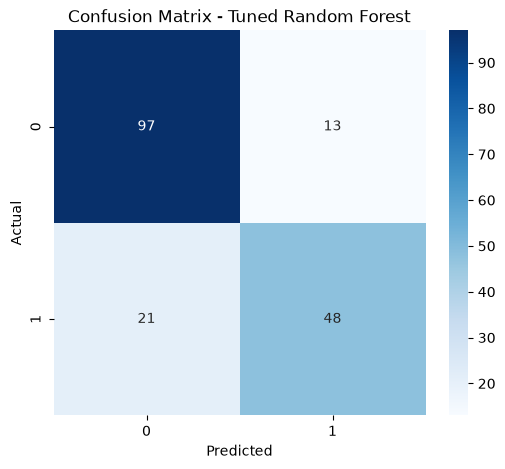

In [23]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

best_rf = grid_search.best_estimator_

y_pred = best_rf.predict(X_test)

print("Classification Report")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Tuned Random Forest")
plt.show()

Feature Importance
sex_male      0.303184
fare          0.254167
age           0.218083
pclass        0.100007
sibsp         0.048898
parch         0.039068
embarked_S    0.026501
embarked_Q    0.010092
dtype: float64


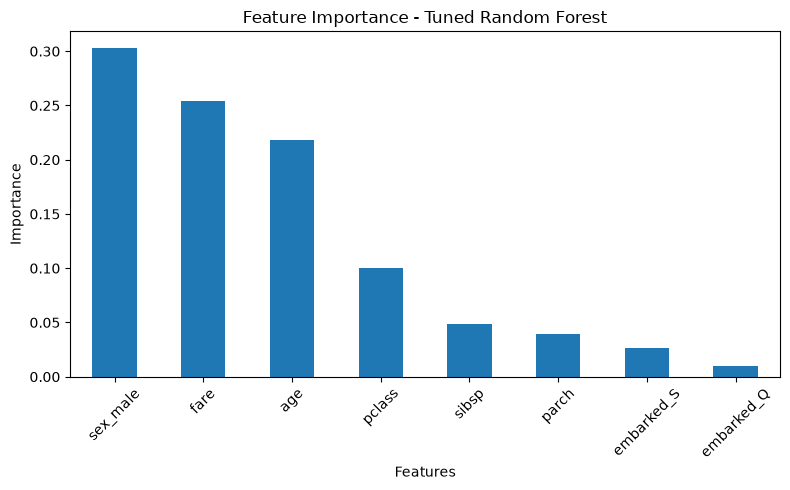

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.Series(
    best_rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print("Feature Importance")
print(feature_importance)

plt.figure(figsize=(8, 5))
feature_importance.plot(kind="bar")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance - Tuned Random Forest")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [25]:
import joblib

loaded_model = joblib.load("random_forest_tuned.joblib")

y_pred_loaded = loaded_model.predict(X_test)

print("Model loaded successfully")
print("Predictions generated successfully")
print("First 10 predictions:", y_pred_loaded[:10])

Model loaded successfully
Predictions generated successfully
First 10 predictions: [0 0 0 0 1 0 1 1 1 0]


In [27]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

X_reg = df.drop(columns=["fare", "survived"])
y_reg = df["fare"]

X_reg = pd.get_dummies(X_reg, drop_first=True)

X_reg = X_reg.fillna(X_reg.median(numeric_only=True))

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

rf_reg = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_reg.fit(X_train_reg, y_train_reg)

y_pred_reg = rf_reg.predict(X_test_reg)

mae = mean_absolute_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
r2 = r2_score(y_test_reg, y_pred_reg)

print("Random Forest Regression Results")
print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

Random Forest Regression Results
MAE: 15.207730990439147
RMSE: 40.834438282562175
R² Score: -0.07756199630278338


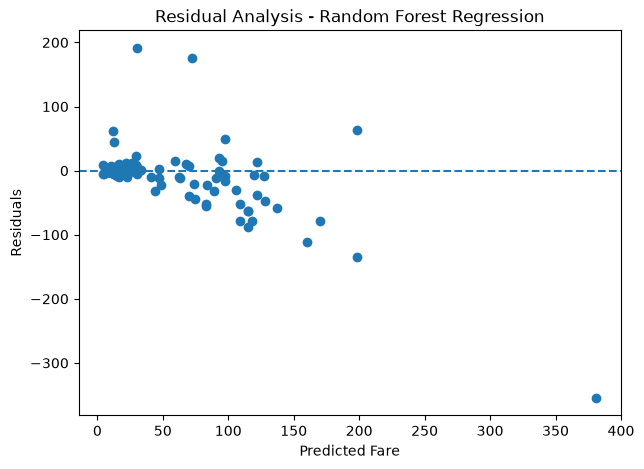

In [28]:
import matplotlib.pyplot as plt

residuals = y_test_reg - y_pred_reg

plt.figure(figsize=(7, 5))
plt.scatter(y_pred_reg, residuals)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Fare")
plt.ylabel("Residuals")
plt.title("Residual Analysis - Random Forest Regression")
plt.show()

In [29]:
import joblib

joblib.dump(rf_reg, "random_forest_regressor.joblib")

print("Regression model saved successfully")

Regression model saved successfully


ROC-AUC Score: 0.836231884057971


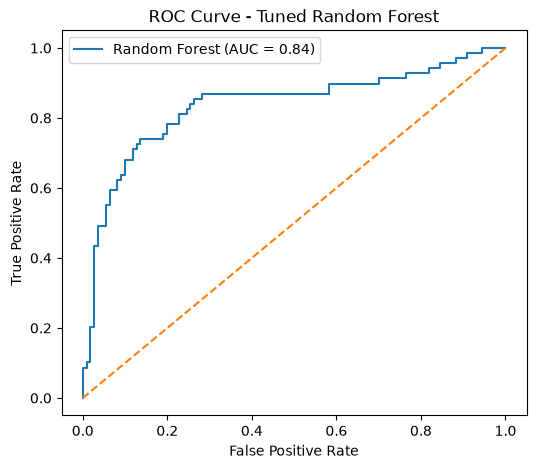

In [30]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_prob = best_rf.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", auc_score)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {auc_score:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Tuned Random Forest")
plt.legend()
plt.show()

In [32]:
import os

files = [
    "model_results.csv",
    "random_forest_tuned.joblib",
    "random_forest_regressor.joblib"
]

for file in files:
    print(file, "->", "FOUND" if os.path.exists(file) else "MISSING")

model_results.csv -> FOUND
random_forest_tuned.joblib -> FOUND
random_forest_regressor.joblib -> FOUND
